In [13]:
# Setup Cell: import all dependencies and define global constants

import marimo as mo

# standard/numerical
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# qiskit
# we avoid the pattern `from qiskit.submodule import Class` to make it clear in each cell where each function/class comes from
import qiskit
import qiskit.visualization
import qiskit_ibm_runtime
import qiskit_aer

# bosonic
import importlib
import importlib.util
import site
import sys
import types
from pathlib import Path

from bosonic_converters import CircuitConverters # sufficiently self-explanatory

def _find_package_path(name):
    module = sys.modules.get(name)
    module_path = getattr(module, "__path__", None)
    if module_path:
        return str(next(iter(module_path)))

    try:
        spec = importlib.util.find_spec(name)
    except ValueError:
        spec = None

    if spec is not None and spec.submodule_search_locations:
        return str(spec.submodule_search_locations[0])

    for base in [*site.getsitepackages(), site.getusersitepackages(), *sys.path]:
        if not base:
            continue
        candidate = Path(base) / name
        if candidate.is_dir():
            return str(candidate)

    raise ModuleNotFoundError(f"No module named {name!r}")

def _ensure_namespace_package(name, path):
    module = sys.modules.get(name)
    if module is None:
        module = types.ModuleType(name)
    module.__path__ = [str(path)]
    sys.modules[name] = module
    return module

_bosonic_sdk_path = _find_package_path("bosonic_sdk")
_ensure_namespace_package("bosonic_sdk", _bosonic_sdk_path)
_ensure_namespace_package("bosonic_sdk.distributor", f"{_bosonic_sdk_path}/distributor")
_ensure_namespace_package(
    "bosonic_sdk.distributor.distributors",
    f"{_bosonic_sdk_path}/distributor/distributors",
)
_ensure_namespace_package("bosonic_sdk.simulation", f"{_bosonic_sdk_path}/simulation")

BosonicDistributor = importlib.import_module(
    "bosonic_sdk.distributor.distributors.bosonic_distributor"
).BosonicDistributor
GateStatistics = importlib.import_module("bosonic_sdk.gate_statistics").GateStatistics
Simulator = importlib.import_module("bosonic_sdk.simulation.simulator").Simulator
bosonic_sdk = types.SimpleNamespace(
    BosonicDistributor=BosonicDistributor,
    GateStatistics=GateStatistics,
    Simulator=Simulator,
)

# filter warnings
import warnings
warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
)

# config constants
VERIFY_CFG = {
    'N_LIST': range(3, 21), # circuit sizes to sweep over
    'SHOTS': 2048, # number of times to simulate each circuit
    'SEED': 1234, # RNG seed to ensure reproducibility
}

SCALING_CFG = {
    'N_LIST': range(3, 128),
    'QUBITS_PER_TRAP': 32,
}

TTS_CFG = {
    'SHOTS': 1024,
    'N_LIST': range(5, 126, 5),
    'QUBITS_PER_TRAP': 128,
    'IBM_TIMING': {
        't1q': 2e-8, # average one-qubit gate duration
        't2q': 2e-7, # average two-qubit gate duration
        't_meas': 1e-6, # average measurement duration
        't_overhead': 2e-4, # device/control overhead
        'e1q': 5e-4, # average one-qubit gate error
        'e2q': 3e-3, # average two-qubit gate error
    },
    'BOSONIC_TIMING': {
        't1q': 1e-6,
        't2q': 3e-5,
        't_meas': 4e-4,
        't_overhead': 1e-3,
        'e1q': 1e-6,
        'e2q': 1e-4,
    },
    'TIMING': {
        'IBM': {
            't1q': 2e-8, # average one-qubit gate duration
            't2q': 2e-7, # average two-qubit gate duration
            't_meas': 1e-6, # average measurement duration
            't_overhead': 2e-4, # device/control overhead
            'e1q': 5e-4, # average one-qubit gate error
            'e2q': 3e-3, # average two-qubit gate error
        },
        'Bosonic': {
            't1q': 1e-6,
            't2q': 3e-5,
            't_meas': 4e-4,
            't_overhead': 1e-3,
            'e1q': 1e-6,
            'e2q': 1e-4,
        },
    },
    'P_SUCCESS_FLOOR': 1e-300,
    'TTS_PLOT_MAX': 1e+12,
    'GROWTH_SWEEP_MAX_N': 126,
    'IBM_OPTIMIZATION_LEVEL': 1, # just to speed things up
}

# Introduction


The goal of the notebook is to explore how distributed quantum computing approaches compare to their monolithic counterparts. To keep scaling behavior consistent, we choose an easy scalable circuit family: GHZ states.

The notebook is split into three main sections:

1. **Generating GHZ circuits** – We use GHZ circuits because they are simple and easy to follow. This simplicity (one more qubit = one more CNOT gate) lets us focus on differences between monolithic and distributed approaches without having to worry about other effects as we scale.
2. **Validation** – We validate correctness by sampling GHZ circuits and checking expected outputs using two simulators:
   - Qiskit Aer (monolithic simulator)
   - Bosonic simulator (distributed simulator)
3. **Exploration** – After validation, we study scaling from two perspectives:
   - Circuit metrics: depth, gate counts, and related compiled-circuit characteristics
   - Hardware metrics: an execution-time model that includes practical hardware considerations

Finally, we will use the following notation:

- *$n$*: number of qubits
- "remote" or "cross-module" gates: two-qubit interactions whose endpoints lie in different modules (two-qubit gates between qubits in different modules).

# GHZ Circuit Generator

Now that we have installed all dependencies and given an overview of the notebook content, we can start building our test circuit. A Greenberger-Horne-Zeilinger (GHZ) state on $n$ qubits is defined as:

$$
\lvert \mathrm{GHZ}_n \rangle
=
\frac{1}{\sqrt{2}}
\left(
\lvert 00\ldots 0_n \rangle
+
\lvert 11\ldots 1_n \rangle
\right)
=
\frac{1}{\sqrt{2}}
\left(
\lvert 0 \rangle^{\otimes n}
+
\lvert 1 \rangle^{\otimes n}
\right).
$$

After measuring all qubits in the computational basis, the ideal outcome distribution is:

$$
\Pr(x) = \begin{cases}
\frac{1}{2}, & x = 0^n \text{ or } 1^n \\
0, & \text{otherwise}
\end{cases}
$$

The circuit that generates this state is simple and involves two steps:

1. Apply $H$ to qubit $0$.
2. Apply $\mathrm{CX}(0 \to i)$ for $i = 1, \dots, n-1$.

In [14]:
def ghz_circuit(n: int, measure: bool = True) -> qiskit.QuantumCircuit:
    """Create a GHZ state circuit on n qubits."""
    qc = qiskit.QuantumCircuit(n, n)
    # qc = QuantumCircuit(n, n)
    qc.h(0)
    for i in range(1, n):
        qc.cx(0, i)
    if measure:
        qc.measure(range(n), range(n))
    return qc

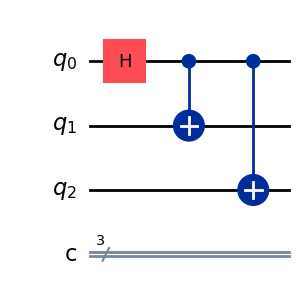

In [15]:
ghz_circuit(3, measure=False).draw("mpl")

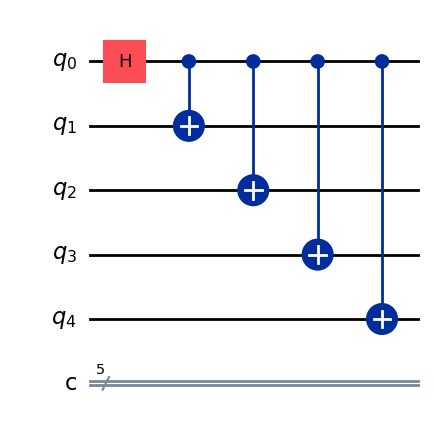

In [16]:
ghz_circuit(5, measure=False).draw("mpl")

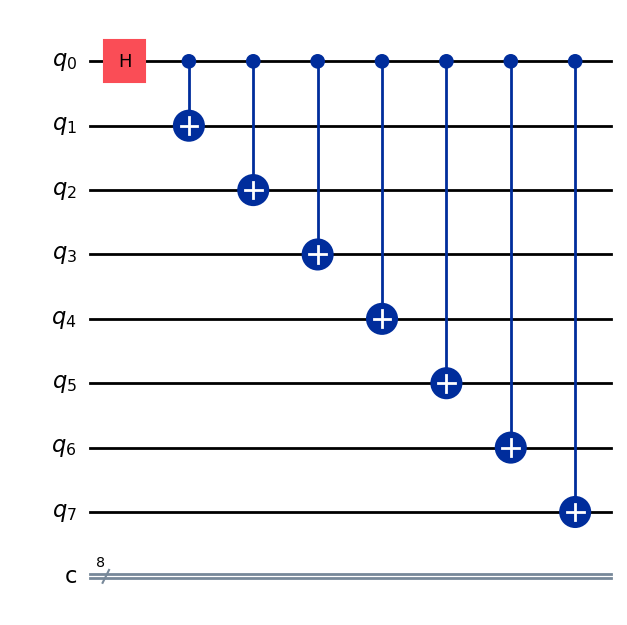

In [17]:
ghz_circuit(8, measure=False).draw("mpl")

# Validating the Circuits

Now that we have defined our circuit, the next step is to verify their behavior by confirming that simulations return the expected measurement distribution.

The simulators return measurement `counts` over `SHOTS` samples. For an ideal GHZ state, we expect roughly an equal amount of $0^n$ and $1^n$ measurements:

$$
\texttt{counts}[0^n] \approx \frac{\texttt{SHOTS}}{2},
\qquad
\texttt{counts}[1^n] \approx \frac{\texttt{SHOTS}}{2},
$$

and all other bitstrings should never be measured.

We use these counts to define a simple fidelity proxy to ensure that we are measuring what we expect:

$$
\widehat{F}_{\mathrm{GHZ}}(n)
=
\frac{\texttt{counts}[0^n] + \texttt{counts}[1^n]}{\texttt{SHOTS}}.
$$

- $\widehat{F}_{\mathrm{GHZ}}(n) = 1$ means that we measured nothing but the expected bitstrings and our simulators are working as intended.
- $\widehat{F}_{\mathrm{GHZ}}(n) < 1$ means that we measured at least one incorrect bitstring. Without any noise models this means that our simulators are not working as expected.

In the following section, for each circuit size $n$, we:

- Simulate the circuit
- Collect measurement counts
- Compute and plot the proxy scores

We start by defining the parameters of our circuit sweep:

In [18]:
VERIFY_CFG

{'N_LIST': range(3, 21), 'SHOTS': 2048, 'SEED': 1234}

## Monolithic Circuit Simulation

To simulate monolithic circuits, we will use Qiskit's Aer simulator transpiled to IBM's [`FakeSherbrooke`](https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/fake-provider-fake-sherbrooke) backend, a (non-existent) 127-qubit QPU.

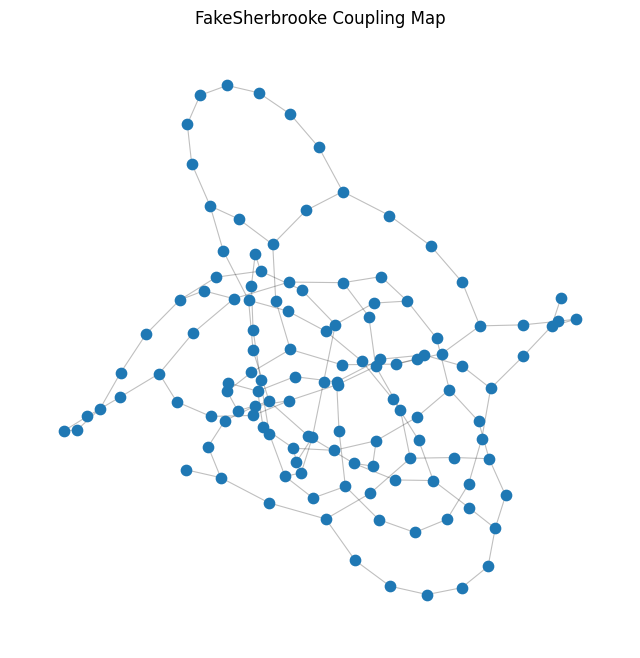

In [19]:
FAKE_IBM_BACKEND = qiskit_ibm_runtime.fake_provider.FakeSherbrooke()
try:
    qiskit.visualization.plot_gate_map(FAKE_IBM_BACKEND)
except qiskit.exceptions.MissingOptionalLibraryError:
    import networkx as nx

    _graph = nx.Graph()
    _graph.add_nodes_from(range(FAKE_IBM_BACKEND.num_qubits))
    _graph.add_edges_from(FAKE_IBM_BACKEND.coupling_map.get_edges())
    _pos = nx.spring_layout(_graph, seed=VERIFY_CFG['SEED'])
    plt.figure(figsize=(8, 8))
    nx.draw_networkx_edges(_graph, _pos, alpha=0.25, width=0.8)
    nx.draw_networkx_nodes(_graph, _pos, node_size=55)
    plt.title('FakeSherbrooke Coupling Map')
    plt.axis('off')
    plt.show()

Notice how the qubits are laid out. All of the CNOT gates involved in our GHZ circuit can't happen directly because each qubit is touching at most three neighboring qubits. This means lots of SWAP gates, with the number of SWAPs increasing as more distant qubits need to be entangled.

Let's start with the basics of running a circuit through the IBM simulator. First, we'll define a GHZ circuit with only $n=3$ qubits:

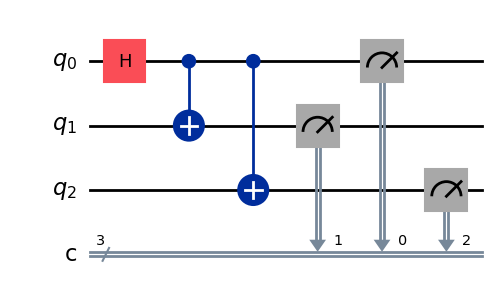

In [20]:
ibm_circ3 = ghz_circuit(3)
ibm_circ3.draw('mpl')

This is called the *logical circuit* and has only a few gate layers.

In [21]:
ibm_circ3.depth()

4

Next, we *transpile* the circuit to the hardware backend, replacing the logical gates with equivalent operations that are allowed on the hardware, restricted by:

1. **Native gate set** – set of unitaries the hardware can physically execute
2. **Connectivity** – entangling gates can only be performed on qubits that are adjacent in the hardware gate map

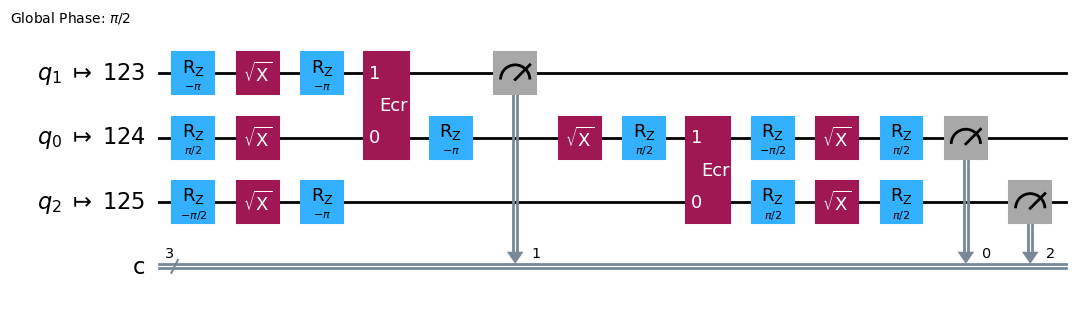

In [22]:
ibm_transpiled3 = qiskit.transpile(ibm_circ3, backend=FAKE_IBM_BACKEND)
ibm_transpiled3.draw('mpl')

Notice how we no longer have H and CNOT gates; they've been replaced with the gates that can actually be performed by the hardware, and you'll notice that the first and third qubits are never directly entangled (because they aren't physically connected on the QPU). Transpilation will typically increase the gate depth because logical gates have to be broken down into multiple physical gates to actually run on hardware.

In [23]:
ibm_transpiled3.depth()

12

Now that we have a circuit that can run on real (fake?) hardware, let's simulate it!

In [24]:
ibm_result3 = qiskit_aer.AerSimulator().run(ibm_transpiled3, shots=VERIFY_CFG['SHOTS']).result()
ibm_result3.to_dict()

{'backend_name': 'aer_simulator',
 'backend_version': '0.17.2',
 'date': '2026-04-27T00:16:04.337140',
 'header': None,
 'job_id': 'fca24228-b6e2-4730-a0dc-164088c9e123',
 'status': 'COMPLETED',
 'success': True,
 'results': [{'shots': 2048,
   'success': True,
   'data': {'counts': {'0x0': 1050, '0x7': 998}},
   'meas_level': <MeasLevel.CLASSIFIED: 2>,
   'header': {'creg_sizes': [['c', 3]],
    'global_phase': 1.570796326794901,
    'memory_slots': 3,
    'n_qubits': 127,
    'name': 'circuit-52',
    'qreg_sizes': [['q', 127]],
    'metadata': {}},
   'status': 'DONE',
   'seed_simulator': 3068020795,
   'metadata': {'time_taken': 0.075688377,
    'num_bind_params': 1,
    'parallel_state_update': 8,
    'parallel_shots': 1,
    'required_memory_mb': 0,
    'input_qubit_map': [[125, 2], [124, 1], [123, 0]],
    'method': 'stabilizer',
    'device': 'CPU',
    'num_qubits': 3,
    'sample_measure_time': 0.003151891,
    'active_input_qubits': [123, 124, 125],
    'num_clbits': 3,
   

You can see there's a lot of information, but we only care about the measurement counts, which we can access with the `get_counts()` method:

In [25]:
ibm_result3.get_counts()

{'000': 1050, '111': 998}

This is what we expected: only the outcomes `000` and `111` are measured, meaning we (most likely) successfully created a GHZ state!

Let's go ahead and compute the proxy measure we came up with earlier:

$$
\widehat{F}_{\mathrm{GHZ}}(n)
=
\frac{\texttt{counts}[0^n] + \texttt{counts}[1^n]}{\texttt{SHOTS}}.
$$

In [26]:
def ghz_fidelity_proxy(counts):
    n = min(len(k) for k in counts.keys()) # compute n using length of measured bitstrings
    shots = sum(counts.values()) # sum measurement counts over all bitstrings
    return (counts.get('0' * n, 0) + counts.get('1' * n, 0)) / shots

In [27]:
ghz_fidelity_proxy(ibm_result3.get_counts())

1.0

Now that we know how the simulator behaves and what data we need, let's write a function to handle the other cases we want to study:

In [28]:
def verify_ghz_ibm(n, shots=VERIFY_CFG['SHOTS']):
    circ = qiskit.transpile(ghz_circuit(n), backend=FAKE_IBM_BACKEND)
    counts = qiskit_aer.AerSimulator().run(circ, shots=shots).result().get_counts()
    data = {
        'backend': 'IBM',
        'n': n,
        'depth': circ.depth(),
        'count0': counts.get('0' * n, 0),
        'count1': counts.get('1' * n, 0),
    }
    return data

In [29]:
ibm_data = [verify_ghz_ibm(n) for n in VERIFY_CFG['N_LIST']]
pd.DataFrame(ibm_data)

,backend,n,depth,count0,count1
0,IBM,3,12,1018,1030
1,IBM,4,18,1051,997
2,IBM,5,27,970,1078
3,IBM,6,43,1042,1006
4,IBM,7,57,1057,991
5,IBM,8,74,1018,1030
6,IBM,9,91,1054,994
7,IBM,10,106,1022,1026
8,IBM,11,94,1013,1035
9,IBM,12,123,1010,1038


## Distributed Circuit Simulation

Next, we simulate the same circuit distributed over multiple modules using the [Bosonic SDK]([https://](https://github.com/dqc-community/dqcomp)):

In [30]:
# TODO: explain distributor.distribute API (or write docs upstream and show them here)
def compile_bosonic_circuit(circuit, n, modules, distributor):
    """Distribute a Qiskit circuit across Bosonic modules and return a Qiskit circuit."""
    distributed = distributor.distribute(
        CircuitConverters.from_qiskit(circuit),
        nodes=int(modules),
        qubits_per_node=np.ceil(n / modules).astype(int),
        lowered=True,
    ).as_monolithic_circuit()
    return CircuitConverters.to_qiskit(distributed)

In [31]:
compile_bosonic_circuit(
    ghz_circuit(3), 3, 2, bosonic_sdk.BosonicDistributor()
).depth()

12

In [32]:
def verify_ghz_bosonic(n, shots=VERIFY_CFG['SHOTS'], traps=2):
    distributor = bosonic_sdk.BosonicDistributor()
    circuit = compile_bosonic_circuit(ghz_circuit(n), n, traps, distributor)
    counts, _ = bosonic_sdk.Simulator().run_counts(circuit, ignore_c_remote=True, shots=shots)
    data = {
        'backend': 'Bosonic',
        'n': n,
        'depth': circuit.depth(),
        'count0': counts.get('0' * n, 0),
        'count1': counts.get('1' * n, 0),
    }
    return data

In [33]:
bosonic_data = [verify_ghz_bosonic(n) for n in VERIFY_CFG['N_LIST']]
pd.DataFrame(bosonic_data)

,backend,n,depth,count0,count1
0,Bosonic,3,12,1047,1001
1,Bosonic,4,19,1016,1032
2,Bosonic,5,21,1016,1032
3,Bosonic,6,28,1015,1033
4,Bosonic,7,30,1015,1033
5,Bosonic,8,37,1023,1025
6,Bosonic,9,39,1023,1025
7,Bosonic,10,46,1010,1038
8,Bosonic,11,48,1010,1038
9,Bosonic,12,55,990,1058


In [34]:
verify_df = pd.DataFrame(ibm_data + bosonic_data)
verify_df

,backend,n,depth,count0,count1
0,IBM,3,12,1018,1030
1,IBM,4,18,1051,997
2,IBM,5,27,970,1078
3,IBM,6,43,1042,1006
4,IBM,7,57,1057,991
5,IBM,8,74,1018,1030
6,IBM,9,91,1054,994
7,IBM,10,106,1022,1026
8,IBM,11,94,1013,1035
9,IBM,12,123,1010,1038


## Analysis and Comparison

Let's first verify that our circuits have produced the expected measurement distribution.

First, we want to check that we aren't measuring any bitstrings other than $0^n$ and $1^n$, so we can verify:

$$
\frac{
    \texttt{counts}\left[ 0^n \right] + \texttt{counts}\left[ 1^n \right]
}{
    \texttt{SHOTS}
} = 1
$$

In [35]:
verify_df['fidelity'] = (verify_df['count0'] + verify_df['count1']) / VERIFY_CFG['SHOTS']

Also, we want to make sure that both outcomes are being measured with equal probability.

$$
\left\vert
\frac{
    \texttt{counts}\left[ 0^n \right] - \texttt{counts}\left[ 1^n \right]
}{
    \texttt{SHOTS}
} \right\vert \approx 0
$$

In [36]:
verify_df['dispersion'] = np.abs(verify_df['count0'] - verify_df['count1']) / VERIFY_CFG['SHOTS']

Now we just check that:

1. `fidelity` is never below 1
2. `dispersion` is never too far above 0

In [37]:
verify_df.groupby('backend').agg(
    min_fidelity=('fidelity', 'min'),
    max_dispersion=('dispersion', 'max'),
)

,min_fidelity,max_dispersion
backend,,
Bosonic,1.0,0.033203
IBM,1.0,0.053711


Both checks pass! To get a better sense of what the data look like, let's plot the sampled measurement probabilities in 2D space:

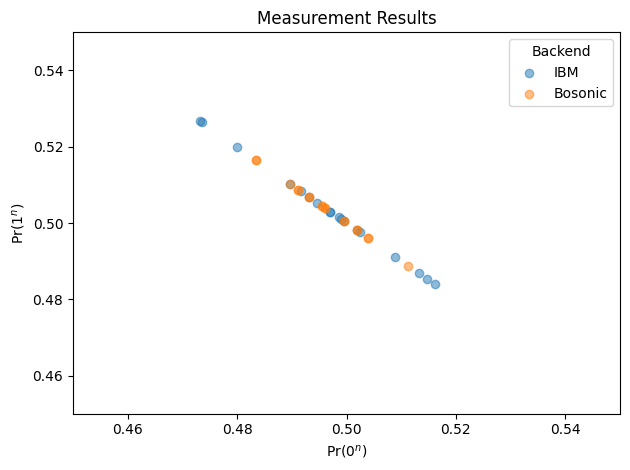

In [38]:
for _backend in ['IBM', 'Bosonic']:
    subdf = verify_df[verify_df['backend'] == _backend]
    plt.scatter(
        subdf['count0'] / VERIFY_CFG['SHOTS'], 
        subdf['count1'] / VERIFY_CFG['SHOTS'], 
        label=_backend,
        alpha=0.5,
    )

plt.xlabel(r'$\Pr(0^n)$')
plt.xlim(0.45, 0.55)

plt.ylabel(r'$\Pr(1^n)$')
plt.ylim(0.45, 0.55)

plt.title('Measurement Results')
plt.legend(title='Backend')

plt.tight_layout()
plt.show()

Notice that all measurement probabilities:

1. Fall on the line where $\Pr(0^n) + \Pr(1^n) = 1$
2. Are close to $\Pr(0^n) = \Pr(1^n) = 0.5$

# Scaling Behavior

Now that we have verified that our simulators are behaving as expected, we can explore how these circuits scale in each system.

For now we will focus on the following metrics (but you can look at other metrics later):

- `depth`: longest sequential gate path (time-step count)
- `two_qubit_depth`: longest chain of explicit two-qubit-operation layers
- `two_qubit_count`: total number of two-qubit operations
- `total_ops`: total operation count

For each backend and circuit size $n$, we:

1. Build the logical GHZ circuit
2. Compile and measure monolithic metrics
3. Compile and measure distributed metrics with dynamic module count $k = \lceil \frac{n}{20} \rceil$
4. Plot each metric against $n$ to compare growth trends

To keep the comparison fair, we use a single metric engine ([`GateStatistics.stats`](https://github.com/dqc-community/dqcomp/blob/5e72e369cc81efcc279ceb63468a10659f01a872/packages/bosonic-sdk/bosonic_sdk/gate_statistics.py#L157-L163)) for both paths so metric definitions stay consistent.

In [39]:
SCALING_CFG

{'N_LIST': range(3, 128), 'QUBITS_PER_TRAP': 32}

## Defining Metrics

We want to include all of the data we can get. First, let's see what kind of information gets collected in `bosonic_sdk.GateStatistics.stats`:

In [40]:
bosonic_sdk.GateStatistics.stats(
    CircuitConverters.from_qiskit(ghz_circuit(5))
)

{'n_qubits': 5,
 'n_clbits': 5,
 'total_ops': 5,
 'depth': 6,
 'gate_counts': {'h': 1, 'cx': 4},
 'basis_gates': ['cx', 'h'],
 'measure_count': 5,
 'reset_count': 0,
 'barrier_count': 0,
 'local_gate_count': 5,
 'remote_gate_count': 0,
 'total_remote_gates': 0,
 'qubit_teleportation_count': 0,
 'n_classical_gates': 0}

This tells us plenty about local vs. remote operations, but it doesn't provide granular information about which types of local gates were executed, etc. We can collect this directly from the Qiskit circuit representation:

In [41]:
def qiskit_metrics(circuit):
    count_ops = lambda x: sum(inst.operation.name == x for inst in circuit.data)
    gate_ops = [inst for inst in circuit.data if inst.operation.name not in ['measure', 'reset', 'barrier']]
    data = {
        'measure_count': count_ops('measure'),
        'reset_count': count_ops('reset'),
        'barrier_count': count_ops('barrier'),
        'single_qubit_count': sum(len(inst.qubits) == 1 for inst in gate_ops),
        'two_qubit_count': sum(len(inst.qubits) == 2 for inst in gate_ops),
        'multi_qubit_count': sum(len(inst.qubits) > 2 for inst in gate_ops),
    }
    return data

In [42]:
def circuit_metrics(circuit):
    converted = CircuitConverters.from_qiskit(circuit)
    data = bosonic_sdk.GateStatistics.stats(converted)
    data.update(qiskit_metrics(circuit))
    return data

## Collecting Data

As before, we set up a pipeline for each backend where we:

1. Construct the logical circuit
2. Transpile to the native gate set of the hardware
3. Collect metrics about the circuit

In [43]:
def scale_ibm(n, constructor=ghz_circuit, backend=FAKE_IBM_BACKEND, **transpile_kwargs):
    circuit = qiskit.transpile(constructor(n), backend=FAKE_IBM_BACKEND, **transpile_kwargs)
    data = {'backend': 'IBM', 'n': n, 'k': 1, 'circuit': circuit}
    return data

In [44]:
def scale_bosonic(
    n,
    constructor=ghz_circuit,
    qubits_per_trap=SCALING_CFG['QUBITS_PER_TRAP'],
    distributor=bosonic_sdk.BosonicDistributor(),
):
    k = np.ceil(n / qubits_per_trap).astype(int)
    circuit = compile_bosonic_circuit(constructor(n), n, k, distributor)
    data = {'backend': 'Bosonic', 'n': n, 'k': k, 'circuit': circuit}
    return data

Now we loop over every value of $n$ we defined in our config, compile a circuit, and collect the circuit metrics into a `DataFrame`.

In [45]:
if mo.running_in_notebook():
    _iter = mo.status.progress_bar(
        SCALING_CFG['N_LIST'],
        title='Compiling',
        subtitle='Monolithic IBM backend',
    )
else:
    _iter = SCALING_CFG['N_LIST']

ibm_circuits = [scale_ibm(n, optimization_level=3) for n in _iter]

In [46]:
if mo.running_in_notebook():
    _iter = mo.status.progress_bar(
        SCALING_CFG['N_LIST'],
        title='Compiling',
        subtitle='Distributed Bosonic backend',
    )
else:
    _iter = SCALING_CFG['N_LIST']

bosonic_circuits = [scale_bosonic(n) for n in _iter]

In [47]:
circuit_df = pd.DataFrame(ibm_circuits + bosonic_circuits)
circuit_df.loc[:, circuit_df.columns != 'circuit'] # including circuit column breaks marimo display

,backend,n,k
0,IBM,3,1
1,IBM,4,1
2,IBM,5,1
3,IBM,6,1
4,IBM,7,1
...,...,...,...
245,Bosonic,123,4
246,Bosonic,124,4
247,Bosonic,125,4
248,Bosonic,126,4


In [48]:
_metrics = lambda g: pd.Series(circuit_metrics(g['circuit']))
scaling_df = circuit_df.join(circuit_df.apply(_metrics, axis=1))
scaling_df.loc[:, scaling_df.columns != 'circuit']

,backend,n,k,n_qubits,n_clbits,total_ops,depth,gate_counts,basis_gates,measure_count,reset_count,barrier_count,local_gate_count,remote_gate_count,total_remote_gates,qubit_teleportation_count,n_classical_gates,single_qubit_count,two_qubit_count,multi_qubit_count
0,IBM,3,1,127,3,19,12,"{'rz': 11, 'sx': 6, 'ecr': 2}","[ecr, rz, sx]",3,0,0,19,0,0,0,0,17,2,0
1,IBM,4,1,127,4,35,18,"{'rz': 20, 'sx': 12, 'ecr': 3}","[ecr, rz, sx]",4,0,0,35,0,0,0,0,32,3,0
2,IBM,5,1,127,5,50,27,"{'rz': 27, 'sx': 15, 'ecr': 7, 'x': 1}","[ecr, rz, sx, x]",5,0,0,50,0,0,0,0,43,7,0
3,IBM,6,1,127,6,83,32,"{'rz': 46, 'sx': 26, 'ecr': 11}","[ecr, rz, sx]",6,0,0,83,0,0,0,0,72,11,0
4,IBM,7,1,127,7,105,52,"{'rz': 56, 'sx': 34, 'ecr': 15}","[ecr, rz, sx]",7,0,0,105,0,0,0,0,90,15,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,Bosonic,123,4,246,215,1347,702,"{'u': 1041, 'rzz': 214, 'remote_link_psi_minus...","[remote_link_psi_minus, rzz, u]",215,184,0,1255,92,92,92,0,1041,306,0
246,Bosonic,124,4,248,217,1360,709,"{'u': 1051, 'rzz': 216, 'remote_link_psi_minus...","[remote_link_psi_minus, rzz, u]",217,186,0,1267,93,93,93,0,1051,309,0
247,Bosonic,125,4,250,218,1365,711,"{'u': 1055, 'rzz': 217, 'remote_link_psi_minus...","[remote_link_psi_minus, rzz, u]",218,186,0,1272,93,93,93,0,1055,310,0
248,Bosonic,126,4,252,220,1378,718,"{'u': 1065, 'rzz': 219, 'remote_link_psi_minus...","[remote_link_psi_minus, rzz, u]",220,188,0,1284,94,94,94,0,1065,313,0


## Exploring Results

That's a lot of columns, so let's just remind ourselves quickly of what all the variables are:

In [49]:
list(scaling_df.columns)

['backend',
 'n',
 'k',
 'circuit',
 'n_qubits',
 'n_clbits',
 'total_ops',
 'depth',
 'gate_counts',
 'basis_gates',
 'measure_count',
 'reset_count',
 'barrier_count',
 'local_gate_count',
 'remote_gate_count',
 'total_remote_gates',
 'qubit_teleportation_count',
 'n_classical_gates',
 'single_qubit_count',
 'two_qubit_count',
 'multi_qubit_count']

Let's define a function that plots a metric against the circuit size $n$ and test it for a few different metrics:

In [50]:
def plot_scaling_metric(df, metric, **kwargs):
    for _backend in ['IBM', 'Bosonic']:
        subdf = df[df['backend'] == _backend]
        plt.plot(subdf['n'], subdf[metric], label=_backend)

    plt.title(kwargs.get('title', 'Scaling Behavior'))

    plt.xlabel('Number of Qubits')
    plt.xscale(kwargs.get('xscale', 'linear'))
    plt.ylabel(kwargs.get('ylabel', metric))
    plt.yscale(kwargs.get('yscale', 'linear'))
    plt.legend(title='Backend')

    plt.tight_layout()
    plt.show()

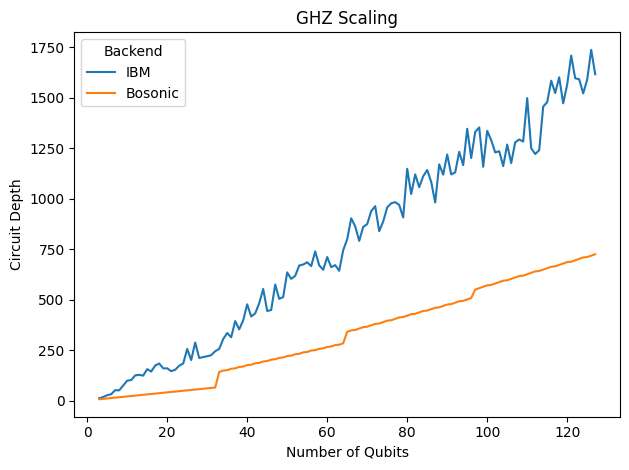

In [51]:
plot_scaling_metric(
    scaling_df, 'depth', title='GHZ Scaling', ylabel='Circuit Depth'
)

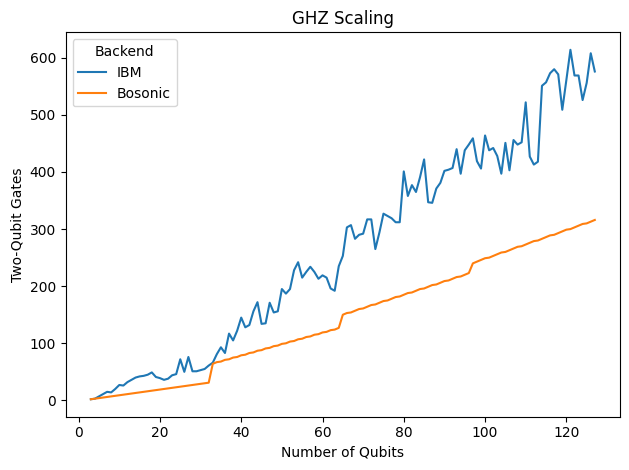

In [52]:
plot_scaling_metric(
    scaling_df, 'two_qubit_count', title='GHZ Scaling', ylabel='Two-Qubit Gates'
)

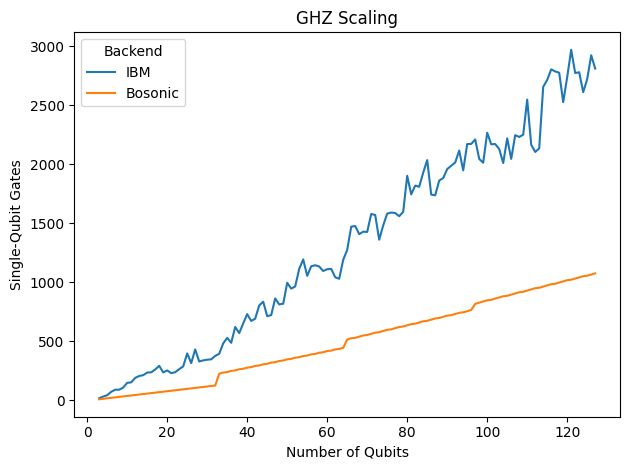

In [53]:
plot_scaling_metric(
    scaling_df, 'single_qubit_count', title='GHZ Scaling', ylabel='Single-Qubit Gates'
)

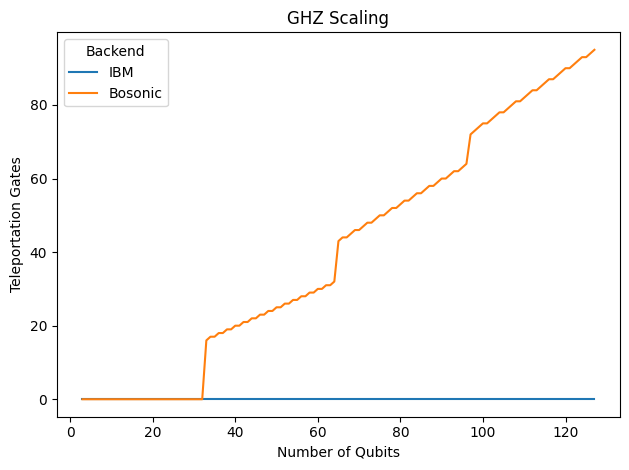

In [54]:
plot_scaling_metric(
    scaling_df, 'qubit_teleportation_count', title='GHZ Scaling', ylabel='Teleportation Gates'
)

## Interpreting Results

Quantum computation is expensive and error-prone, so we generally want to do as little of it as we can get away with. This means we want circuits with fewer operations and shallower paths.

Two-qubit gates are especially important because they are typically slower and noisier (lower fidelity) than single-qubit gates, which is why we tracked `two_qubit_gates` as a metric.

Connectivity plays a huge role in how many additional gates your circuit needs as it scales. In monolithic nearest-neighbor hardware, non-local interactions require routing through SWAP operations. This routing overhead increases depth and total operation count as circuits grows. In the distributed approach we still have to worry about connectivity, but due to the modularity of the hardware communication costs grow linearly with circuit size (i.e., at the same rate as the logical circuit) rather than exponentially.

# Execution Time

So far we have seen how scaling affects the circuit we are implementing. This is useful for building intuition, but at the end of the day we care about the time-to-solution (TTS) when executing on hardware. Accessing real hardware involves provider cost, queue times, and cloud submission overhead. That cost is worth it when we care about running an application circuit, but here we only care about the scaling behavior. To simplify things, we construct a worst-case model for time-to-solution that incorporates the metrics we care about. First, we define the relevant parameters:

In [55]:
TTS_CFG

{'SHOTS': 1024,
 'N_LIST': range(5, 126, 5),
 'QUBITS_PER_TRAP': 128,
 'IBM_TIMING': {'t1q': 2e-08,
  't2q': 2e-07,
  't_meas': 1e-06,
  't_overhead': 0.0002,
  'e1q': 0.0005,
  'e2q': 0.003},
 'BOSONIC_TIMING': {'t1q': 1e-06,
  't2q': 3e-05,
  't_meas': 0.0004,
  't_overhead': 0.001,
  'e1q': 1e-06,
  'e2q': 0.0001},
 'TIMING': {'IBM': {'t1q': 2e-08,
   't2q': 2e-07,
   't_meas': 1e-06,
   't_overhead': 0.0002,
   'e1q': 0.0005,
   'e2q': 0.003},
  'Bosonic': {'t1q': 1e-06,
   't2q': 3e-05,
   't_meas': 0.0004,
   't_overhead': 0.001,
   'e1q': 1e-06,
   'e2q': 0.0001}},
 'P_SUCCESS_FLOOR': 1e-300,
 'TTS_PLOT_MAX': 1000000000000.0,
 'GROWTH_SWEEP_MAX_N': 126,
 'IBM_OPTIMIZATION_LEVEL': 1}

## Building the Model

To begin, we treat a compiled circuit as a collection of single-qubit gates and two-qubit gates. Different gate types can have different execution times, but for a simpler model we assume an average single-qubit gate time $t_{1q}$ and an average two-qubit gate time $t_{2q}$. If we further assume that all gates are executed sequentially (a strong assumption, but it provides an upper bound), one shot of the circuit takes:

$$
T_{\text{shot}}(n)=t_{1q}N_{1q}(n) + t_{2q}N_{2q}(n)
$$

We also assume that measurement takes time $t_{\text{measure}}$ per qubit, and we include a fixed overhead term for classical control, reset, and other per-shot orchestration costs that are only negligibly affected by qubit count. Our time per shot then becomes:

$$
T_{\text{shot}}(n)=t_{1q}N_{1q}(n) + t_{2q}N_{2q}(n) + t_{\text{measure}}n + t_{\text{overhead}}.
$$

- $t_{1q}$ – execution time of a single-qubit gate
- $N_{1q}$ – number of compiled single-qubit gates
- $t_{2q}$ – execution time of a two-qubit gate
- $N_{2q}$ – number of compiled two-qubit gates
- $t_{\text{measure}}$ – measurement time per qubit
- $t_{\text{overhead}}$ – per-shot overhead for classical control and reset
- $n$ – circuit size in number of qubits

In [56]:
def T_shot(circuit_data, device=TTS_CFG['IBM_TIMING']):
    t_compute = (
        device['t1q'] * circuit_data['single_qubit_count'] + 
        device['t2q'] *  circuit_data['two_qubit_count'] + 
        device['t_meas'] * circuit_data['measure_count']
    )
    return t_compute + device['t_overhead']

In an ideal (or at least fault-tolerant) world, we would almost surely obtain the intended result of each shot, so TTS is just $T_\text{shot}$ times the number of shots. (We may still want to run multiple shots because we care about the distribution over measurements and not a single solution bitstring.) But taking into account noise (and the absence of error correction in our circuits) the probability of measuring the correct result vanishes exponentially with circuit depth. We will take a look at what circuits with error correcting codes look like in a future demo, but for our present model we assume that the success probability of the full circuit is the product of the success probabilities of the gates that make it up:

$$
P_{\text{success}}(n)=
(1-\epsilon_{1q})^{N_{1q}(n)}
(1-\epsilon_{2q})^{N_{2q}(n)}.
$$

- $\epsilon_{1q}$ – error rate of a single-qubit gate
- $\epsilon_{2q}$ – error rate of a two-qubit gate
- $N_{1q}(n)$ – number of single-qubit gates in the compiled circuit
- $N_{2q}(n)$ – number of two-qubit gates in the compiled circuit

In [57]:
def shot_success_log_prob(circuit_data, device=TTS_CFG['IBM_TIMING']):
    """Independent-gate success proxy from 1Q/2Q error rates."""
    return (
        circuit_data['single_qubit_count'] * np.log1p(-device['e1q']) + 
        circuit_data['two_qubit_count'] * np.log1p(-device['e2q'])
    )

If only a fraction $P_{\text{success}}$ of shots succeed, then the expected time-to-solution increases by a factor of $1/P_{\text{success}}$. Using that correction, the success-adjusted model becomes:

$$
\mathrm{TTS}(n,k) \approx
{S} \cdot
\frac{T_{\text{shot}}(n)}{P_{\text{success}}(n)}.
$$

## Applying the Model

Now that we have defined the basic model functions defined, we can start building some functions to collect simulation data.

In [58]:
def tts_data_series(circuit_data, shots=TTS_CFG['SHOTS']):
    device = TTS_CFG['TIMING'][circuit_data['backend']]
    data = {'log_pr_success': shot_success_log_prob(circuit_data, device=device)}
    data['t_shot'] = T_shot(circuit_data, device=device)
    data['log_t_shot'] = np.log(data['t_shot'])
    data['t_shot_compute'] = data['t_shot'] - device['t_overhead']
    data['log_tts_ideal'] = np.log(shots) + np.log(data['t_shot'])
    data['log_tts'] = data['log_tts_ideal'] - data['log_pr_success']
    data['tts'] = np.exp(data['log_tts'])
    return pd.Series(data)

Let's test out this function for a simple $n=3$ circuit:

In [59]:
_filter_rows = (scaling_df['n'] == 3) & (scaling_df['backend'] == 'IBM')
tts_data_series(scaling_df.loc[_filter_rows, :].iloc[0])

log_pr_success   -0.014511
t_shot            0.000204
log_t_shot       -8.498666
t_shot_compute    0.000004
log_tts_ideal    -1.567194
log_tts          -1.552683
tts               0.211679
dtype: float64

All we have to do is apply this function to our existing simulation data.

In [60]:
tts_df = scaling_df.join(scaling_df.apply(tts_data_series, axis=1))

## Exploring Results

Since we're using the same data structure, we can also re-use our plotting funtions from the previous section:

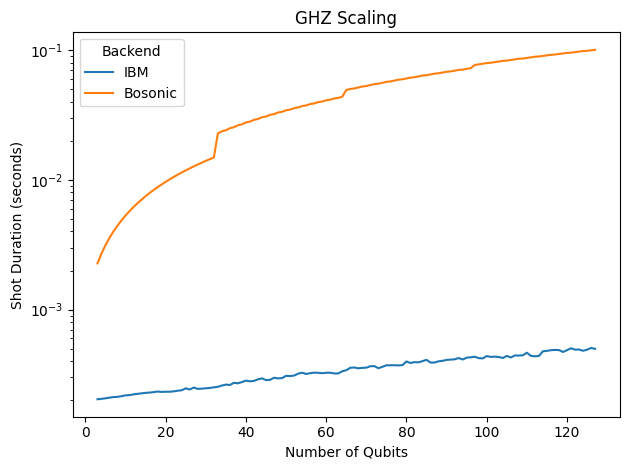

In [61]:
plot_scaling_metric(
    tts_df, 't_shot', title='GHZ Scaling', ylabel='Shot Duration (seconds)', yscale='log',
)

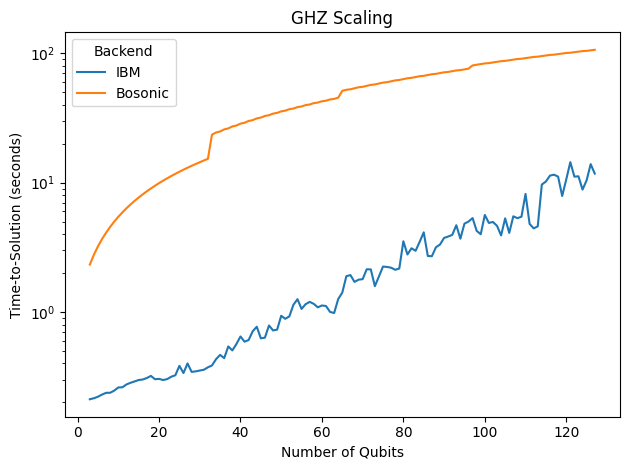

In [62]:
plot_scaling_metric(
    tts_df, 'tts', title='GHZ Scaling', ylabel='Time-to-Solution (seconds)', yscale='log',
)

## Interpreting Results

Both of these plots show the same pattern. The monolithic superconducting backend has lower shot times and TTS everywhere, but both of them grow quickly with circuit size.

1. Shot time grows because of the number of SWAP operations necessary to entangle increasingly distant qubits.
2. TTS grows exponential (i.e., its log grows linearly) because not only are shots getting longer, but gate depth and therefore shot fidelity is decreasing, which exponentially increases the number of shots required to reach a solution.

For the trapped-ion backend, shot speed and TTS is much higher, but both grow much more slowly. Shot speed grows approximately linearly, since each additional qubit is just another direct CNOT. TTS grows faster, but the high physical fidelities of trapped ions keep the extra number of shots from growing too quickly.

We've reached the maximum number of qubits in the `FakeSherbrooke` backend, but it looks like the two TTS lines would cross if we could keep adding qubits. So let's try that!

# Extrapolating to Utility Scale

The IBM device caps out at 127 qubits, to get around this limitation (and avoid expensive compilation of gigantic circuits) we can use the data we have from our current simulation and assume that we would see a similar pattern as we extend to utility-scale regimes (assuming that the IBM chip would have the same heavy-hex structure at larger qubit counts).

The graphs suggest we see a linear increase in gate counts on both monolithic and distributed systems. Assuming we continue to scale linearly, we can use a line of best fit to extrapolate to the utility scale regime we want to explore.

For each hardware backend, we:

1. Fit a linear model of gate type (single-qubit, two-qubit, measurement) on $n$
2. Use predicted gate counts in the same TTS model
3. Plot projected complexity and TTS on log scales (to handle very large numbers)

## Fitting a Linear Model

We already have all the data we need to from our earlier simulations; the tricky part is getting it into the shape that we need. We can do some `pandas` magic to get a `DataFrame` where each row is a data point we can use in our linear model by combining some of our columns using `melt`:

In [63]:
df_linear_fit = scaling_df.melt(
    id_vars = ['backend', 'n'],
    value_vars = ['single_qubit_count', 'two_qubit_count', 'measure_count'],
    var_name = 'gate_type',
    value_name = 'gate_count',
)
df_linear_fit

,backend,n,gate_type,gate_count
0,IBM,3,single_qubit_count,17
1,IBM,4,single_qubit_count,32
2,IBM,5,single_qubit_count,43
3,IBM,6,single_qubit_count,72
4,IBM,7,single_qubit_count,90
...,...,...,...,...
745,Bosonic,123,measure_count,215
746,Bosonic,124,measure_count,217
747,Bosonic,125,measure_count,218
748,Bosonic,126,measure_count,220


Now we have our linear predictor `n` and our response `gate_count`, and we can group the data by `backend` and `gate_type` to get one fit for each combination:

In [64]:
def _fit(g):
    slope, intercept = np.polyfit(g['n'], g['gate_count'], 1)
    return pd.Series({'slope': slope, 'intercept': intercept})

fits = (
    df_linear_fit.groupby(['backend', 'gate_type'])
    .apply(_fit, include_groups=False)
    .reset_index()
)
fits

,backend,gate_type,slope,intercept
0,Bosonic,measure_count,1.864289,-1.564277e+01
1,Bosonic,single_qubit_count,9.185733,-9.685663e+01
2,Bosonic,two_qubit_count,2.728578,-3.228554e+01
3,IBM,measure_count,1.000000,2.481074e-15
4,IBM,single_qubit_count,23.724688,-2.211527e+02
5,IBM,two_qubit_count,4.926034,-5.568820e+01


Now if we add `n` as a column, we can compute the predicted `gate_count` in each row:

In [65]:
_preds = fits.copy()
_preds['n'] = 10000
_preds['gate_count_predicted'] = np.ceil(
    _preds['intercept'] + _preds['slope'] * _preds['n']
).astype(int)
_preds

,backend,gate_type,slope,intercept,n,gate_count_predicted
0,Bosonic,measure_count,1.864289,-1.564277e+01,10000,18628
1,Bosonic,single_qubit_count,9.185733,-9.685663e+01,10000,91761
2,Bosonic,two_qubit_count,2.728578,-3.228554e+01,10000,27254
3,IBM,measure_count,1.000000,2.481074e-15,10000,10000
4,IBM,single_qubit_count,23.724688,-2.211527e+02,10000,237026
5,IBM,two_qubit_count,4.926034,-5.568820e+01,10000,49205


Now we just need to add more values for $n$! We can create a new `DataFrame` and perform a cross join to get all possible combinations (one $n$ for each backend and gate type):

In [66]:
fits.merge(pd.DataFrame({'n': np.logspace(3, 5, 10).astype(int)}), how='cross')

,backend,gate_type,slope,intercept,n
0,Bosonic,measure_count,1.864289,-1.564277e+01,1000
1,Bosonic,measure_count,1.864289,-1.564277e+01,1668
2,Bosonic,measure_count,1.864289,-1.564277e+01,2782
3,Bosonic,measure_count,1.864289,-1.564277e+01,4641
4,Bosonic,measure_count,1.864289,-1.564277e+01,7742
5,Bosonic,measure_count,1.864289,-1.564277e+01,12915
6,Bosonic,measure_count,1.864289,-1.564277e+01,21544
7,Bosonic,measure_count,1.864289,-1.564277e+01,35938
8,Bosonic,measure_count,1.864289,-1.564277e+01,59948
9,Bosonic,measure_count,1.864289,-1.564277e+01,100000


Let's put the whole process into a function:

In [67]:
def gate_count_prediction(fits, nvals):
    preds = fits.merge(pd.DataFrame({'n': nvals}), how='cross')
    preds['gate_count_predicted'] = np.ceil(
        preds['intercept'] + preds['slope'] * preds['n']
    ).astype(int)
    return preds.pivot_table( # go back to one column for each gate type
        index=['backend', 'n'],
        columns='gate_type',
        values='gate_count_predicted',
        aggfunc='first',
    ).reset_index()

In [68]:
pred_df = gate_count_prediction(fits, np.logspace(1, 5, 24).astype(int))
pred_df

gate_type,backend,n,measure_count,single_qubit_count,two_qubit_count
0,Bosonic,10,4,-4,-4
1,Bosonic,14,11,32,6
2,Bosonic,22,26,106,28
3,Bosonic,33,46,207,58
4,Bosonic,49,76,354,102
5,Bosonic,74,123,583,170
6,Bosonic,110,190,914,268
7,Bosonic,164,291,1410,416
8,Bosonic,246,443,2163,639
9,Bosonic,367,669,3275,970


Now that we have our gate counts, we can reuse our TTS data computation functions from earlier to get our new results:

In [69]:
extrapolation_df = pred_df.join(pred_df.apply(tts_data_series, axis=1))

/tmp/ipykernel_19533/1610044842.py:9: RuntimeWarning: overflow encountered in exp
  data['tts'] = np.exp(data['log_tts'])


## Interpreting Results

As before, we plot the (predicted) metrics we care about to see how they scale with circuit size.

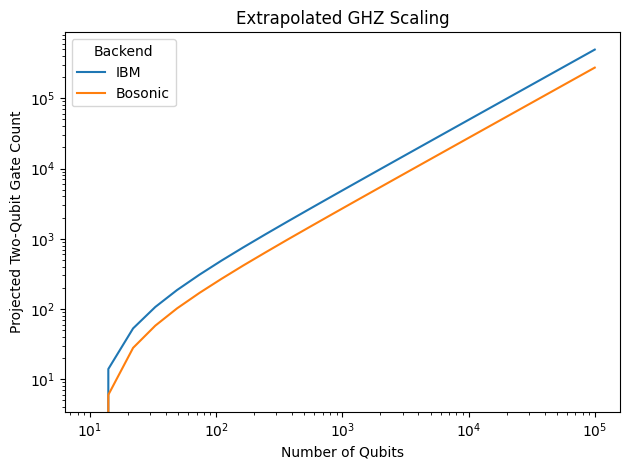

In [70]:
plot_scaling_metric(
    extrapolation_df, 'two_qubit_count', 
    title='Extrapolated GHZ Scaling', 
    xscale='log', yscale='log', ylabel='Projected Two-Qubit Gate Count'
)

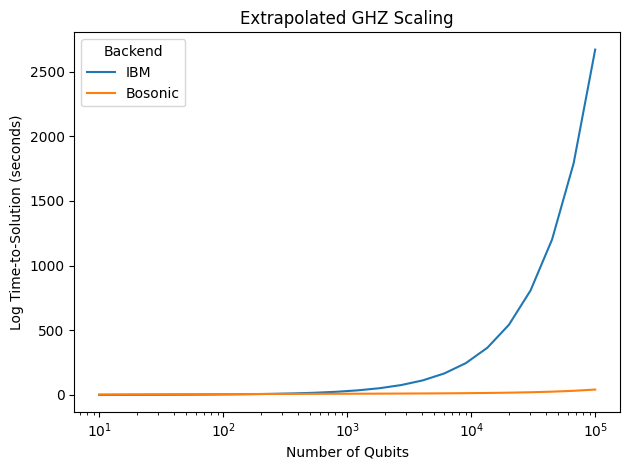

In [71]:
# TODO: add ylim handling
plot_scaling_metric(
    extrapolation_df, 'log_tts', 
    title='Extrapolated GHZ Scaling', 
    xscale='log', yscale='linear', ylabel='Log Time-to-Solution (seconds)'
)

These projections highlight a key scaling challenge for monolithic approaches.

At small sizes, monolithic circuits with fast native gates can outperform distributed ones by far. As size grows, routing overhead begins to dominate. We explored this on a superconducting system, where distant qubits are entangled via SWAP chains, but routing is still an issue in architectures where qubits can be physically moved around the QPU (shuttling ions with QCCD, shuttling neutral atoms with AOMs, shuttling spin qubits from cell to cell across a silicon chip).

Distributed systems introduce their own challenges (for example remote entanglement and coordination overhead), but they provide a practical path to larger effective system sizes.

# Conclusion

In this notebook we explored how scaling quantum circuits scale between monolithic and distributed architectures strictly in terms of gate counts.

## Relaxing Assumptions

We assumed that gates are executed sequentially, but in many architectures multiple gates on different qubits can happen simultaneously. For the fake IBM backend, we can actually use Qiskit it to inspect the gate timing of a transpiled circuit:

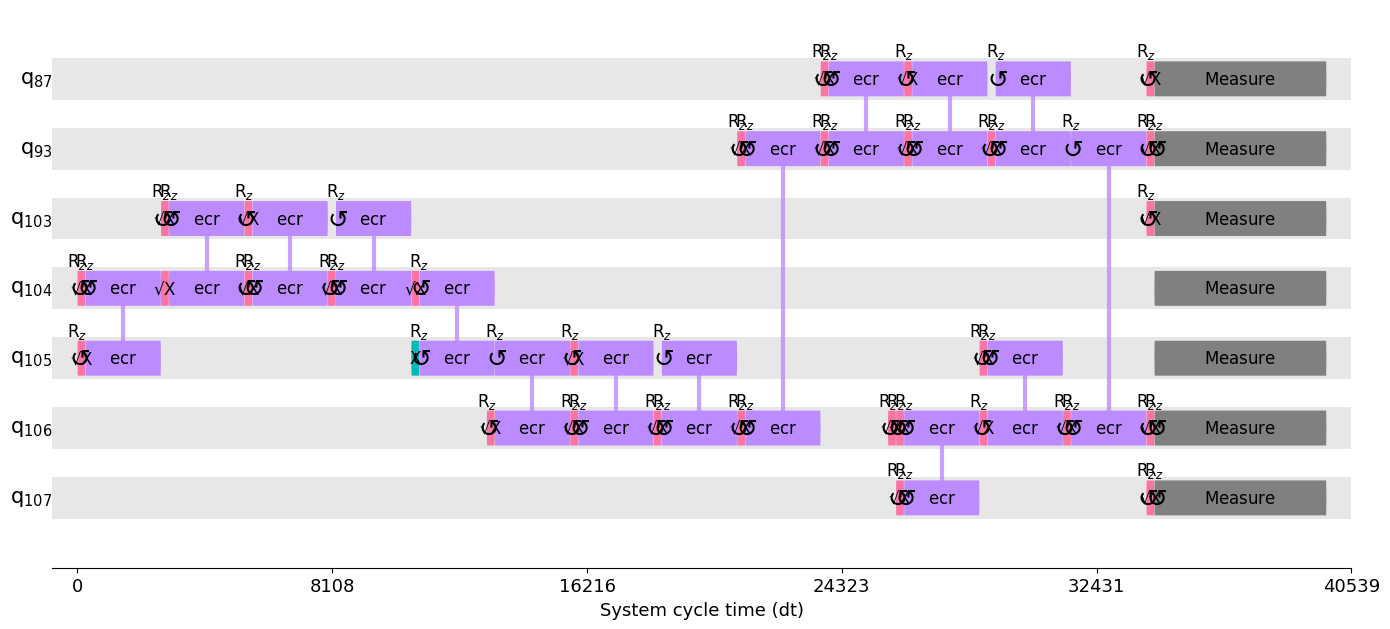

In [72]:
# compilation is non-deterministic – run this cell a few times to see the changes
qiskit.visualization.timeline.draw(
    qiskit.transpile(ghz_circuit(7), backend=FAKE_IBM_BACKEND, optimization_level=3), 
    target=FAKE_IBM_BACKEND.target, 
    show_idle=False,
)

(array([ 7.,  3.,  3.,  3.,  6.,  6., 18.,  4., 16., 34.]),
 array([6.05155556e-06, 6.47608889e-06, 6.90062222e-06, 7.32515556e-06,
        7.74968889e-06, 8.17422222e-06, 8.59875556e-06, 9.02328889e-06,
        9.44782222e-06, 9.87235556e-06, 1.02968889e-05]),
 <BarContainer object of 10 artists>)

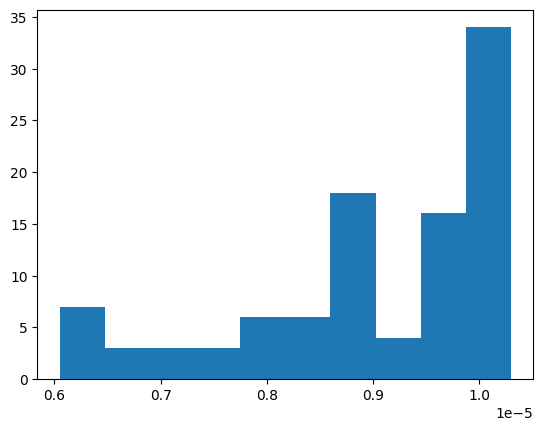

In [73]:
def _duration(n):
    transpiled =  qiskit.transpile(
        ghz_circuit(7), backend=FAKE_IBM_BACKEND, optimization_level=3
    )
    return transpiled.estimate_duration(target=FAKE_IBM_BACKEND.target)

plt.hist(pd.DataFrame({'duration': [_duration(10) for _ in range(100)]}))

## Other Dimensions

However, we neglected one of the biggest advantages that distributed systems have: their ability to run computations in parallel on different modules/QPUs. One can also use this ability to run computations in parallel to run different parts of a circuit at the same time! This is one of the biggest advantages of distributed quantum computing but implementation is not as trivial as one may think. Refer back to the slides to learn more!

---

# Try it Yourself!

You may have noticed that the scaling behaviour for our circuits had the same shape across different metrics. This was due to our choice of using GHZ circuits. As we scaled up we added two exactly one CNOT which made all of our scaling trivial. Below is a sandbox where you can design your own circuit and use all of the tools we have defined to explore scaling using your own circuit!

Start in the cell below by defining your circuit! The only requirement is to add some dependency on the number of qubits $n$ so that your circuit has some sort of scaling and is compatible with all of our functions! This is left as an excercise for your own time or if you get through the notebook earlier than others!

## Build Your Own Experiment

In this section, you can swap in your own circuit family and reuse the same compilation, metric, TTS, and extrapolation tools from the rest of the notebook.

The only requirement is that `circuit_fn(n)` returns a measured Qiskit circuit with `n` qubits.


In [79]:
YOUR_N_LIST = range(9, 46, 9)
YOUR_N_EXTRAP = np.unique(np.logspace(1, 5, 24).astype(int)).tolist()
YOUR_BOSONIC_QUBITS_PER_TRAP = 20
YOUR_METRICS_TO_PLOT = ['two_qubit_count', 'single_qubit_count', 'total_ops']

# Default is a Shor 9 Qubit error correcting circuit 
def circuit_fn(n: int):
    if n % 9 != 0 or n < 9:
        raise ValueError('Use n as a positive multiple of 9 (e.g., 9, 18, 27, ...).')
    _qc = qiskit.QuantumCircuit(n, n)
    n_blocks = n // 9
    for b in range(n_blocks):
        o = 9 * b
        _qc.cx(o + 0, o + 3)
        _qc.cx(o + 0, o + 6)
        _qc.h(o + 0)
        _qc.h(o + 3)
        _qc.h(o + 6)
        for r in [o + 0, o + 3, o + 6]:
            _qc.cx(r, r + 1)
            _qc.cx(r, r + 2)
    _qc.measure(range(n), range(n))
    return _qc


Now compile your circuit family in the same two ways we used for GHZ circuits: once for the monolithic IBM backend and once for the distributed Bosonic backend.


In [80]:
your_circuits = []
for n in YOUR_N_LIST:
    print(f'Compiling circuit_fn({n}) for IBM')
    your_circuits.append(
        scale_ibm(n, constructor=circuit_fn, optimization_level=TTS_CFG['IBM_OPTIMIZATION_LEVEL'])
    )

for n in YOUR_N_LIST:
    print(f'Compiling circuit_fn({n}) for Bosonic')
    your_circuits.append(
        scale_bosonic(
            n,
            constructor=circuit_fn,
            qubits_per_trap=YOUR_BOSONIC_QUBITS_PER_TRAP,
        )
    )

your_circuit_df = pd.DataFrame(your_circuits)
your_circuit_df.loc[:, your_circuit_df.columns != 'circuit']


Compiling circuit_fn(9) for IBM
Compiling circuit_fn(18) for IBM
Compiling circuit_fn(27) for IBM
Compiling circuit_fn(36) for IBM
Compiling circuit_fn(45) for IBM
Compiling circuit_fn(9) for Bosonic
Compiling circuit_fn(18) for Bosonic
Compiling circuit_fn(27) for Bosonic
Compiling circuit_fn(36) for Bosonic
Compiling circuit_fn(45) for Bosonic


,backend,n,k
0,IBM,9,1
1,IBM,18,1
2,IBM,27,1
3,IBM,36,1
4,IBM,45,1
5,Bosonic,9,1
6,Bosonic,18,1
7,Bosonic,27,2
8,Bosonic,36,2
9,Bosonic,45,3


Next, collect the same circuit metrics and TTS estimates used earlier in the notebook.


In [81]:
_your_metrics = lambda g: pd.Series(circuit_metrics(g['circuit']))
your_scaling_df = your_circuit_df.join(your_circuit_df.apply(_your_metrics, axis=1))
your_tts_df = your_scaling_df.join(your_scaling_df.apply(tts_data_series, axis=1))
your_tts_df.loc[:, your_tts_df.columns != 'circuit']


,backend,n,k,n_qubits,n_clbits,total_ops,depth,gate_counts,basis_gates,measure_count,...,single_qubit_count,two_qubit_count,multi_qubit_count,log_pr_success,t_shot,log_t_shot,t_shot_compute,log_tts_ideal,log_tts,tts
0,IBM,9,1,127,9,119,43,"{'rz': 60, 'sx': 37, 'ecr': 20, 'x': 2}","[ecr, rz, sx, x]",9,...,99,20,0,-0.109603,0.000215,-8.444966,0.000015,-1.513494,-1.403891,0.245639
1,IBM,18,1,127,18,238,46,"{'rz': 121, 'sx': 75, 'ecr': 37, 'x': 5}","[ecr, rz, sx, x]",18,...,201,37,0,-0.211692,0.000229,-8.379956,0.000029,-1.448484,-1.236792,0.290314
2,IBM,27,1,127,27,366,44,"{'rz': 176, 'sx': 119, 'ecr': 60, 'x': 11}","[ecr, rz, sx, x]",27,...,306,60,0,-0.333309,0.000245,-8.313763,0.000045,-1.382291,-1.048982,0.350294
3,IBM,36,1,127,36,554,60,"{'sx': 182, 'rz': 263, 'ecr': 92, 'x': 17}","[ecr, rz, sx, x]",36,...,462,92,0,-0.507473,0.000264,-8.240926,0.000064,-1.309454,-0.801982,0.448439
4,IBM,45,1,127,45,648,84,"{'rz': 308, 'sx': 213, 'ecr': 109, 'x': 18}","[ecr, rz, sx, x]",45,...,539,109,0,-0.597059,0.000278,-8.189401,0.000078,-1.257930,-0.660871,0.516402
5,Bosonic,9,1,18,9,43,13,"{'u': 35, 'rzz': 8}","[rzz, u]",9,...,35,8,0,-0.000835,0.004875,-5.323635,0.003875,1.607837,1.608672,4.996170
6,Bosonic,18,1,36,18,86,13,"{'u': 70, 'rzz': 16}","[rzz, u]",18,...,70,16,0,-0.001670,0.008750,-4.738702,0.007750,2.192770,2.194440,8.974976
7,Bosonic,27,2,54,29,145,13,"{'u': 117, 'rzz': 26, 'remote_link_psi_minus': 2}","[remote_link_psi_minus, rzz, u]",29,...,117,28,0,-0.002917,0.013557,-4.300852,0.012557,2.630620,2.633537,13.922924
8,Bosonic,36,2,72,36,172,13,"{'u': 140, 'rzz': 32}","[rzz, u]",36,...,140,32,0,-0.003340,0.016500,-4.104395,0.015500,2.827077,2.830417,16.952530
9,Bosonic,45,3,90,48,239,20,"{'u': 193, 'rzz': 43, 'remote_link_psi_minus': 3}","[remote_link_psi_minus, rzz, u]",48,...,193,46,0,-0.004793,0.021773,-3.827085,0.020773,3.104387,3.109180,22.402676


Choose the metrics you want to inspect by editing `YOUR_METRICS_TO_PLOT` in the first cell of this section.


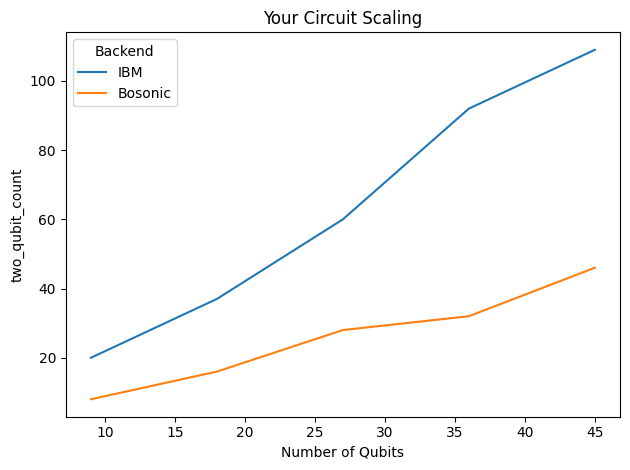

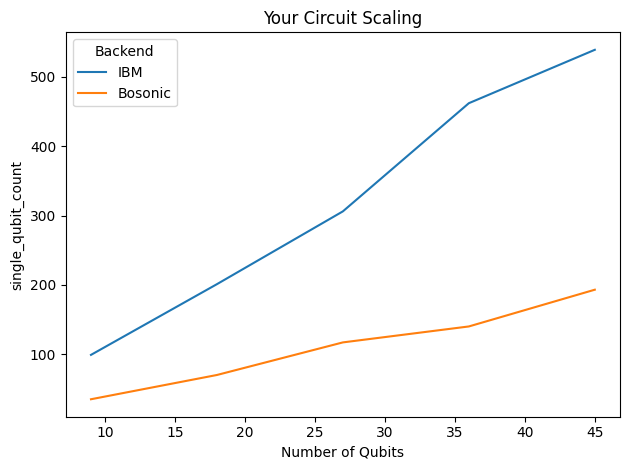

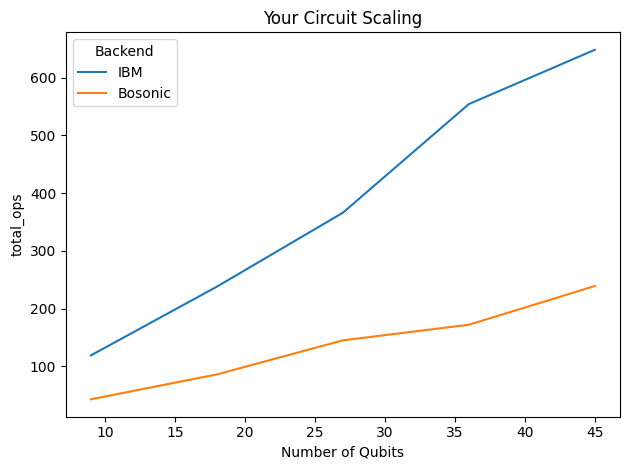

In [82]:
for _metric in YOUR_METRICS_TO_PLOT:
    plot_scaling_metric(
        your_tts_df,
        _metric,
        title='Your Circuit Scaling',
        ylabel=_metric,
    )


Finally, extrapolate your measured gate counts and reuse the same TTS model to estimate how the circuit family might behave at larger sizes.


In [83]:
your_fit_df = your_scaling_df.melt(
    id_vars=['backend', 'n'],
    value_vars=['single_qubit_count', 'two_qubit_count', 'measure_count'],
    var_name='gate_type',
    value_name='gate_count',
)

def _fit_your_circuit(g):
    slope, intercept = np.polyfit(g['n'], g['gate_count'], 1)
    return pd.Series({'slope': slope, 'intercept': intercept})

your_fits = (
    your_fit_df.groupby(['backend', 'gate_type'])
    .apply(_fit_your_circuit, include_groups=False)
    .reset_index()
)

your_pred_df = gate_count_prediction(your_fits, YOUR_N_EXTRAP)
your_extrapolation_df = your_pred_df.join(your_pred_df.apply(tts_data_series, axis=1))
your_extrapolation_df


/tmp/ipykernel_19533/1610044842.py:9: RuntimeWarning: overflow encountered in exp
  data['tts'] = np.exp(data['log_tts'])


,backend,n,measure_count,single_qubit_count,two_qubit_count,log_pr_success,t_shot,log_t_shot,t_shot_compute,log_tts_ideal,log_tts,tts
0,Bosonic,10,10,39,9,-0.000939,0.005309,-5.238352,0.004309,1.693120,1.694059,5.441523e+00
1,Bosonic,14,15,56,13,-0.001356,0.007446,-4.900078,0.006446,2.031394,2.032750,7.635051e+00
2,Bosonic,22,23,90,21,-0.002190,0.010920,-4.517159,0.009920,2.414312,2.416503,1.120660e+01
3,Bosonic,33,35,137,33,-0.003437,0.016127,-4.127260,0.015127,2.804211,2.807649,1.657091e+01
4,Bosonic,49,52,206,49,-0.005106,0.023476,-3.751777,0.022476,3.179695,3.184801,2.416249e+01
5,Bosonic,74,79,313,75,-0.007813,0.035163,-3.347761,0.034163,3.583711,3.591524,3.628935e+01
6,Bosonic,110,117,467,111,-0.011568,0.051597,-2.964292,0.050597,3.967180,3.978748,5.345005e+01
7,Bosonic,164,175,699,167,-0.017400,0.076709,-2.567736,0.075709,4.363736,4.381135,7.992873e+01
8,Bosonic,246,262,1051,250,-0.026052,0.114351,-2.168483,0.113351,4.762989,4.789041,1.201861e+02
9,Bosonic,367,391,1570,374,-0.038972,0.170190,-1.770840,0.169190,5.160632,5.199604,1.812004e+02


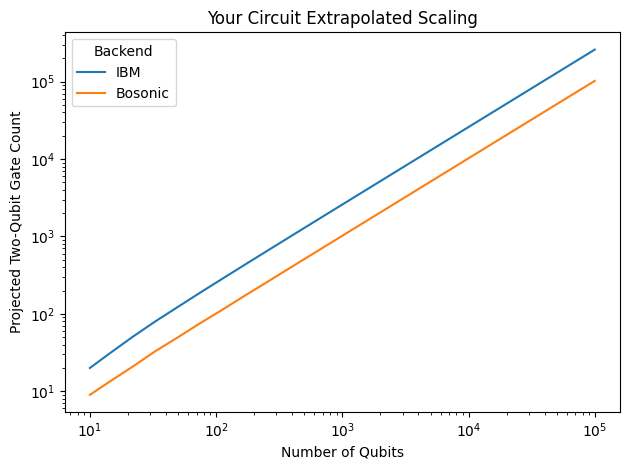

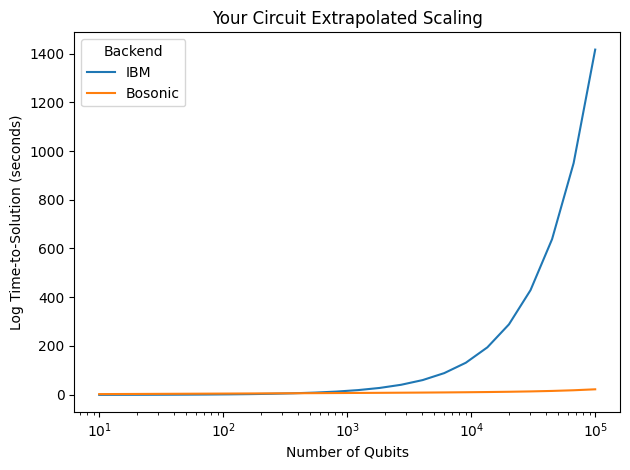

In [84]:
plot_scaling_metric(
    your_extrapolation_df,
    'two_qubit_count',
    title='Your Circuit Extrapolated Scaling',
    xscale='log',
    yscale='log',
    ylabel='Projected Two-Qubit Gate Count',
)

plot_scaling_metric(
    your_extrapolation_df,
    'log_tts',
    title='Your Circuit Extrapolated Scaling',
    xscale='log',
    yscale='linear',
    ylabel='Log Time-to-Solution (seconds)',
)
